# Kalshi vs. the VIX: Who Prices the S&P 500 Better?

Companion notebook to the Medium article. It reloads one CSV (`data/kalshi_spx_vix_quotes.csv`) and reproduces every number, table and figure in the piece.

**Data in the CSV.** One row per Kalshi S&P 500 daily-ladder quote, read at 09:31 ET from 1-minute candles (bid, ask, volume, open interest), joined with the contract result and settlement, the S&P 500 daily open and close (Yahoo Finance), and Cboe volatility indices (VIX, VIX9D, VIX1D, VIX3M, VIX6M, VIX1Y, SKEW) at the previous close. The file is the post-filter sample: two-sided book, spread at most 0.10, stale at most 10 minutes, volume or open interest above zero, strike within 2% of the previous close. 1,735 quotes on 616 days, June 2023 to October 2026.

**Model.** P(S_T > K) = N(d2), d2 = [ln(S0/K) - sigma^2/2] / sigma, zero drift, S0 = day's open, sigma = previous-close volatility index / 100 / sqrt(252) x sqrt(389/390). This is a one-number lognormal, not an option-implied density.

**Fee.** 0.07 p (1-p) per contract is an assumption and has not been checked against Kalshi's current schedule.

In [1]:
import math, json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA = 'data/kalshi_spx_vix_quotes.csv'
FIG = 'figures'; os.makedirs(FIG, exist_ok=True)
SQ, TF = math.sqrt(252.0), math.sqrt(389 / 390)
BLUE, ORNG, GREEN, RED, GREY, INK = '#2B5FAF', '#C8871A', '#2A9D78', '#B5473E', '#8A8D98', '#0E1020'
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': '#C9CBD3', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#ECEDF1', 'axes.axisbelow': True, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.dpi': 160, 'figure.dpi': 90})
R = {}  # every number quoted in the article ends up here

## 0. Helpers

In [2]:
def ncdf(x):
    return 0.5 * (1.0 + np.vectorize(math.erf)(np.asarray(x, float) / math.sqrt(2.0)))

def fee(p, rate):
    return rate * p * (1 - p)

def cboot(df, col, B=2000, seed=7):
    """95% interval of the mean of df[col], day-block bootstrap (all strikes of a day share one outcome)."""
    rng = np.random.default_rng(seed)
    g = df.groupby('date')[col].agg(['sum', 'count'])
    sm, ct = g['sum'].values, g['count'].values.astype(float)
    idx = rng.integers(0, len(sm), (B, len(sm)))
    vals = sm[idx].sum(1) / ct[idx].sum(1)
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def model_p(df, sigma_ann, k=1.0):
    """Zero-drift lognormal P(S_T > K); sigma_ann is the annualised vol in decimals."""
    sg = (sigma_ann / SQ) * TF * k
    return ncdf((np.log(df.spx_open / df.strike) - 0.5 * sg ** 2) / sg)

def sq_gap(df, col):
    """Per-quote squared error of model minus squared error of Kalshi mid."""
    return (df[col] - df.result) ** 2 - (df.mid - df.result) ** 2

## 1. Load and sanity-check the data

In [3]:
s = pd.read_csv(DATA); s['date'] = pd.to_datetime(s['date'])
s['mid'] = (s.bid + s.ask) / 2
s['yr'] = s.date.dt.year
print(s.shape, s.date.min().date(), s.date.max().date())
display(s.head(3).T)

# sanity gate: known answers. A unit bug (dollar strings divided by 100 again) once showed up as these failing.
print('yes rate overall            :', round(s.result.mean(), 4))
print('mean mid                    :', round(s.mid.mean(), 4))
low = s[s.mid <= 0.05]; high = s[s.mid >= 0.95]
print('yes rate when mid <= 0.05   :', round(low.result.mean(), 4), f'(n={len(low)})')
print('yes rate when mid >= 0.95   :', round(high.result.mean(), 4), f'(n={len(high)})')
assert low.result.mean() < 0.10 and high.result.mean() > 0.90, 'units look wrong'

cov = s.groupby('yr').agg(quotes=('mid', 'size'), days=('date', 'nunique'))
display(cov)
R['n'], R['days'] = int(len(s)), int(s.date.nunique())
R['by_year'] = {int(y): {'n': int(r.quotes), 'days': int(r.days)} for y, r in cov.iterrows()}
print('months with quotes:', s.date.dt.to_period('M').nunique(), '| gap check (no quotes Nov 2024 - Jan 2025):',
      s[(s.date >= '2024-11-01') & (s.date < '2025-02-01')].shape[0] == 0)

(1735, 28) 2023-06-28 2026-10-08


,0,1,2
date,2023-06-28 00:00:00,2023-06-29 00:00:00,2023-07-03 00:00:00
event,INXDU-23JUN28,INXDU-23JUN29,INXDU-23JUL03
ticker,INXDU-23JUN28-T4374.99,INXDU-23JUN29-T4374.99,INXDU-23JUL03-T4449.99
family,INXDU,INXDU,INXDU
strike,4374.99,4374.99,4449.99
result,1,1,1
settle,4376.86,4396.44,4455.59
bid,0.32,0.46,0.33
ask,0.38,0.51,0.41
cum_vol,0.0,186.0,277.0


yes rate overall            : 0.5533
mean mid                    : 0.5465
yes rate when mid <= 0.05   : 0.0096 (n=209)
yes rate when mid >= 0.95   : 0.9925 (n=265)


,quotes,days
yr,,
2023,60,46
2024,290,177
2025,439,204
2026,946,189


months with quotes: 38 | gap check (no quotes Nov 2024 - Jan 2025): True


## 2. Benchmarks: Kalshi against four raw volatility models

In [4]:
s['sg1d'] = s.VIX1D / 100
s['p_vix'] = model_p(s, s.VIX / 100)
s['p_vix9d'] = model_p(s, s.VIX9D / 100)
s['p_vix1d'] = model_p(s, s.VIX1D / 100)
# EWMA(0.94) of close-to-close returns, precomputed in the CSV from Kalshi settlement levels (no look-ahead)
sg_e = s.ewma * TF
s['p_ewma'] = ncdf((np.log(s.spx_open / s.strike) - 0.5 * sg_e ** 2) / sg_e)

R['brier_kalshi_all'] = float(((s.mid - s.result) ** 2).mean())
R['brier_5050'] = float(((0.5 - s.result) ** 2).mean())
print('Kalshi mid Brier:', round(R['brier_kalshi_all'], 4), '| always-50% Brier:', round(R['brier_5050'], 4))

def compare(df, col):
    x = df.dropna(subset=[col]).copy(); x['v'] = sq_gap(x, col); lo, hi = cboot(x, 'v')
    return dict(n=len(x), brier=float(((x[col] - x.result) ** 2).mean()), gap=float(x.v.mean()), lo=lo, hi=hi)

names = {'p_vix': 'VIX (30-day)', 'p_vix9d': 'VIX9D', 'p_vix1d': 'VIX1D', 'p_ewma': 'EWMA of past returns'}
tab1 = pd.DataFrame({names[c]: compare(s, c) for c in names}).T
R['table1'] = tab1.to_dict('index')
display(tab1.round(4))

Kalshi mid Brier: 0.1133 | always-50% Brier: 0.25


,n,brier,gap,lo,hi
VIX (30-day),1735.0,0.1292,0.0159,0.0117,0.0197
VIX9D,1735.0,0.1258,0.0125,0.0085,0.0163
VIX1D,1735.0,0.1209,0.0076,0.0039,0.0111
EWMA of past returns,1721.0,0.1221,0.0091,0.0053,0.0128


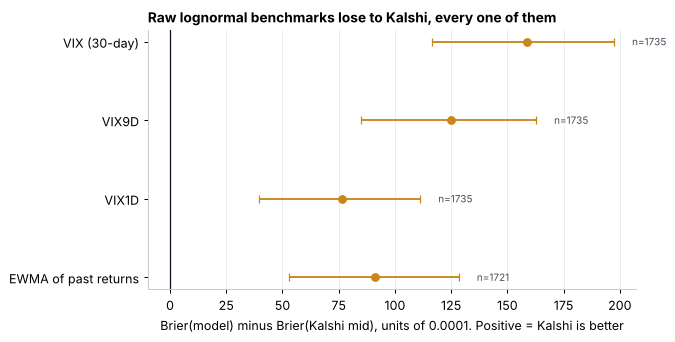

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 3.9))
for i, (lab, r) in enumerate(tab1.iterrows()):
    ax.errorbar(r.gap * 1e4, i, xerr=[[(r.gap - r.lo) * 1e4], [(r.hi - r.gap) * 1e4]], fmt='o', color=ORNG, capsize=3, ms=6)
    ax.text(r.hi * 1e4 + 8, i, f'n={int(r.n)}', va='center', fontsize=8, color='#4A4D5A')
ax.axvline(0, color=INK, lw=1); ax.set_yticks(range(len(tab1))); ax.set_yticklabels(tab1.index); ax.invert_yaxis()
ax.set_xlabel('Brier(model) minus Brier(Kalshi mid), units of 0.0001. Positive = Kalshi is better')
ax.set_title('Raw lognormal benchmarks lose to Kalshi, every one of them', loc='left', fontsize=11, fontweight='bold')
ax.grid(axis='y', visible=False); fig.tight_layout(); fig.savefig(f'{FIG}/f1_brier_models.png'); plt.show()

## 3. Calibration and the size of the mismatch

k fitted on 350 quotes before 2025: 0.68 | on full sample: 0.65


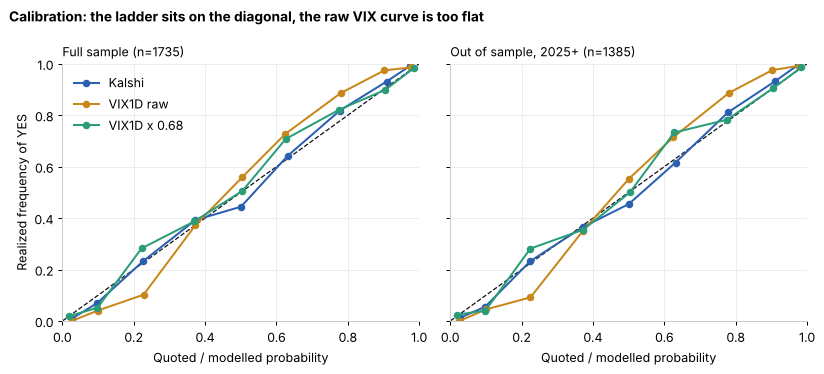

In [6]:
def fit_k(df, grid=np.arange(0.50, 1.2001, 0.01)):
    best, bb = None, 9.0
    for k in grid:
        b = ((model_p(df, df.VIX1D / 100, k) - df.result) ** 2).mean()
        if b < bb: bb, best = b, k
    return float(round(best, 2))

train = s[s.date < '2025-01-01']; test = s[s.date >= '2025-01-01'].copy()
k_tr = fit_k(train); R['k_train'], R['k_all'] = k_tr, fit_k(s)
s['p_sc'] = model_p(s, s.VIX1D / 100, k_tr); test['p_sc'] = s.loc[test.index, 'p_sc']
print(f'k fitted on {len(train)} quotes before 2025: {k_tr} | on full sample: {R["k_all"]}')

def rel(p, y, edges):
    g = pd.DataFrame({'p': p, 'y': y, 'b': pd.cut(p, edges, include_lowest=True)}).groupby('b', observed=True).agg(p=('p', 'mean'), y=('y', 'mean'), n=('y', 'size'))
    return g[g.n >= 15]
edges = [0, .05, .15, .30, .45, .55, .70, .85, .95, 1.0]
fig, axs = plt.subplots(1, 2, figsize=(9.2, 4.2), sharey=True)
for ax, (df, ttl) in zip(axs, [(s, f'Full sample (n={len(s)})'), (test, f'Out of sample, 2025+ (n={len(test)})')]):
    ax.plot([0, 1], [0, 1], color=INK, lw=1, ls='--')
    for col, lab, c in [('mid', 'Kalshi', BLUE), ('p_vix1d', 'VIX1D raw', ORNG), ('p_sc', f'VIX1D x {k_tr:.2f}', GREEN)]:
        g = rel(df[col], df.result, edges); ax.plot(g.p, g.y, '-o', color=c, ms=5, lw=1.6, label=lab)
    ax.set_title(ttl, loc='left', fontsize=10); ax.set_xlabel('Quoted / modelled probability'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axs[0].set_ylabel('Realized frequency of YES'); axs[0].legend(frameon=False, loc='upper left')
fig.suptitle('Calibration: the ladder sits on the diagonal, the raw VIX curve is too flat', x=0.01, ha='left', fontsize=11, fontweight='bold')
fig.tight_layout(); fig.savefig(f'{FIG}/f2_calibration.png'); plt.show()

### Realized vs implied moves, and the overnight gap

overnight share of close-to-close variance: 0.2873
0.94 x sqrt(1 - share) = 0.797 | measured open-to-close: 0.784


,cc,oc,n
VIX1D,0.944,0.784,616.0
VIX9D,0.876,0.728,616.0
VIX,0.844,0.701,616.0


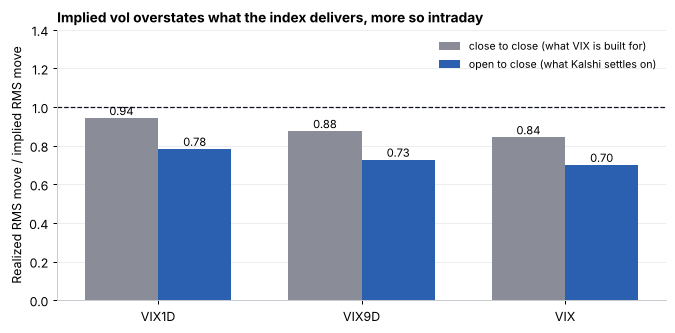

In [7]:
days = s.groupby('date').first().reset_index()
days['r_cc'] = np.log(days.spx_close / days.prev_close)
days['r_oc'] = np.log(days.spx_close / days.spx_open)
days['r_on'] = np.log(days.spx_open / days.prev_close)
R['overnight_var_share'] = float((days.r_on ** 2).mean() / (days.r_cc ** 2).mean())
rat = {}
for n, c in [('VIX1D', 'VIX1D_spxprev'), ('VIX9D', 'VIX9D_spxprev'), ('VIX', 'VIX_spxprev')]:
    a = days.dropna(subset=[c, 'r_cc']); sg = a[c] / 100 / SQ
    rat[n] = dict(cc=float(math.sqrt((a.r_cc ** 2).mean()) / math.sqrt((sg ** 2).mean())),
                  oc=float(math.sqrt((a.r_oc ** 2).mean()) / math.sqrt(((sg * TF) ** 2).mean())), n=len(a))
R['rms_ratio'] = rat
print('overnight share of close-to-close variance:', round(R['overnight_var_share'], 4))
print('0.94 x sqrt(1 - share) =', round(rat['VIX1D']['cc'] * math.sqrt(1 - R['overnight_var_share']), 3), '| measured open-to-close:', round(rat['VIX1D']['oc'], 3))
display(pd.DataFrame(rat).T.round(3))

fig, ax = plt.subplots(figsize=(7.6, 3.8)); x = np.arange(3); w = .36; names3 = ['VIX1D', 'VIX9D', 'VIX']
b1 = ax.bar(x - w / 2, [rat[n]['cc'] for n in names3], w, color=GREY, label='close to close (what VIX is built for)')
b2 = ax.bar(x + w / 2, [rat[n]['oc'] for n in names3], w, color=BLUE, label='open to close (what Kalshi settles on)')
for bars in (b1, b2):
    for r in bars: ax.text(r.get_x() + r.get_width() / 2, r.get_height() + .015, f'{r.get_height():.2f}', ha='center', fontsize=9)
ax.axhline(1, color=INK, lw=1, ls='--'); ax.set_xticks(x); ax.set_xticklabels(names3); ax.set_ylim(0, 1.4)
ax.set_ylabel('Realized RMS move / implied RMS move'); ax.legend(frameon=False, loc='upper right', fontsize=8.5)
ax.set_title('Implied vol overstates what the index delivers, more so intraday', loc='left', fontsize=11, fontweight='bold')
ax.grid(axis='x', visible=False); fig.tight_layout(); fig.savefig(f'{FIG}/f3_realized_vs_implied.png'); plt.show()

## 4. One scaling constant, fitted before 2025 and tested after

In [8]:
R['brier_kalshi_test'] = float(((test.mid - test.result) ** 2).mean())
out = {}
for lab, df in [('full sample', s), ('2025+ out of sample', test)]:
    out[lab] = {'VIX1D raw': compare(df, 'p_vix1d'), f'VIX1D x {k_tr}': compare(df, 'p_sc')}
R['scaled'] = out
display(pd.concat({k: pd.DataFrame(v).T for k, v in out.items()}).round(4))
print('Kalshi Brier 2025+:', round(R['brier_kalshi_test'], 4))

n   brier     gap      lo      hi
full sample         VIX1D raw     1735.0  0.1209  0.0076  0.0039  0.0111
                    VIX1D x 0.68  1735.0  0.1154  0.0021 -0.0014  0.0056
2025+ out of sample VIX1D raw     1385.0  0.1166  0.0078  0.0036  0.0120
                    VIX1D x 0.68  1385.0  0.1108  0.0020 -0.0023  0.0062

Kalshi Brier 2025+: 0.1088


## 5. Regimes: VIX level, term structure, SKEW

regime         model    n  \
By VIX level                      0            VIX<14     VIX1D raw  146   
                                  1            VIX<14  VIX1D scaled  146   
                                  2             14-17     VIX1D raw  759   
                                  3             14-17  VIX1D scaled  759   
                                  4             17-22     VIX1D raw  631   
                                  5             17-22  VIX1D scaled  631   
                                  6               >22     VIX1D raw  199   
                                  7               >22  VIX1D scaled  199   
By term structure (VIX9D / VIX3M) 0        9D/3M<0.80     VIX1D raw  891   
                                  1        9D/3M<0.80  VIX1D scaled  891   
                                  2         0.80-0.90     VIX1D raw  446   
                                  3         0.80-0.90  VIX1D scaled  446   
                                  4         0.90-1.00     VIX1D raw  244   
                                  5         0.90-1.00  VIX1D scaled  244   
                                  6  >1.00 (inverted)     VIX1D raw  154   
                                  7  >1.00 (inverted)  VIX1D scaled  154   
By SKEW tercile                   0          SKEW low     VIX1D raw  580   
                                  1          SKEW low  VIX1D scaled  580   
                                  2          SKEW mid     VIX1D raw  577   
                                  3          SKEW mid  VIX1D scaled  577   
                                  4         SKEW high     VIX1D raw  578   
                                  5         SKEW high  VIX1D scaled  578   

                                     days     gap      lo      hi  
By VIX level                      0    98  0.0082 -0.0010  0.0168  
                                  1    98 -0.0002 -0.0076  0.0072  
                                  2   248  0.0086  0.0034  0.0137  
                                  3   248  0.0037 -0.0024  0.0099  
                                  4   201  0.0049 -0.0020  0.0110  
                                  5   201  0.0003 -0.0055  0.0057  
                                  6    69  0.0123  0.0036  0.0205  
                                  7    69  0.0034 -0.0053  0.0119  
By term structure (VIX9D / VIX3M) 0   299  0.0082  0.0035  0.0130  
                                  1   299  0.0033 -0.0020  0.0088  
                                  2   159  0.0070 -0.0018  0.0154  
                                  3   159  0.0002 -0.0071  0.0071  
                                  4   103  0.0073  0.0002  0.0147  
                                  5   103  0.0017 -0.0052  0.0086  
                                  6    55  0.0066 -0.0032  0.0157  
                                  7    55  0.0015 -0.0082  0.0110  
By SKEW tercile                   0   218  0.0103  0.0051  0.0153  
                                  1   218  0.0044 -0.0012  0.0101  
                                  2   167  0.0066  0.0002  0.0127  
                                  3   167 -0.0004 -0.0069  0.0062  
                                  4   231  0.0059 -0.0015  0.0127  
                                  5   231  0.0023 -0.0042  0.0085

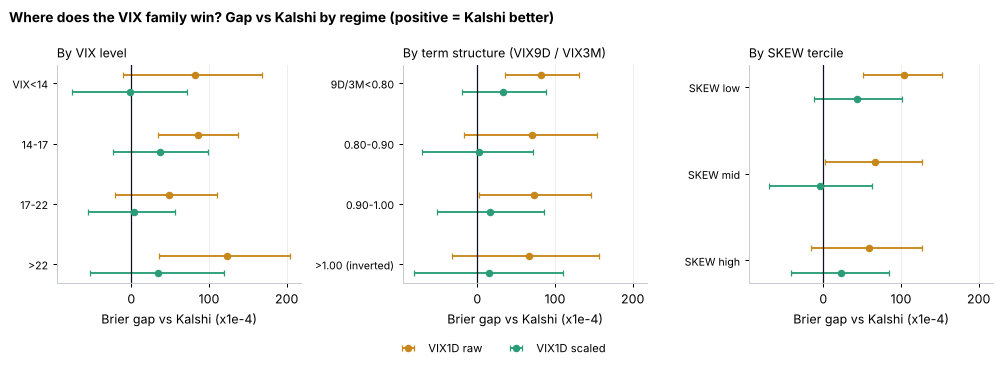

In [9]:
s['inv'] = s.VIX9D / s.VIX3M
def regime_rows(col, bins, labels):
    t = s.dropna(subset=[col]).copy(); t['r'] = pd.cut(t[col], bins, labels=labels); rows = []
    for lab, g in t.groupby('r', observed=True):
        if len(g) < 40: continue
        for mc, ml in [('p_vix1d', 'VIX1D raw'), ('p_sc', 'VIX1D scaled')]:
            x = g.assign(v=sq_gap(g, mc)); lo, hi = cboot(x, 'v')
            rows.append(dict(regime=str(lab), model=ml, n=len(g), days=g.date.nunique(), gap=float(x.v.mean()), lo=lo, hi=hi))
    return rows
q1, q2 = s.SKEW.quantile([1 / 3, 2 / 3])
reg = {'By VIX level': regime_rows('VIX', [0, 14, 17, 22, 100], ['VIX<14', '14-17', '17-22', '>22']),
       'By term structure (VIX9D / VIX3M)': regime_rows('inv', [0, .80, .90, 1.0, 10], ['9D/3M<0.80', '0.80-0.90', '0.90-1.00', '>1.00 (inverted)']),
       'By SKEW tercile': regime_rows('SKEW', [0, q1, q2, 999], ['SKEW low', 'SKEW mid', 'SKEW high'])}
R['regimes'] = reg
display(pd.concat({k: pd.DataFrame(v) for k, v in reg.items()}).round(4))
fig, axs = plt.subplots(1, 3, figsize=(11.2, 4.0), sharex=True)
for ax, (ttl, rows) in zip(axs, reg.items()):
    labs = list(dict.fromkeys(r['regime'] for r in rows))
    for j, (ml, c) in enumerate([('VIX1D raw', ORNG), ('VIX1D scaled', GREEN)]):
        for i, lab in enumerate(labs):
            r = [r for r in rows if r['regime'] == lab and r['model'] == ml][0]; y = i + (j - .5) * .28
            ax.errorbar(r['gap'] * 1e4, y, xerr=[[(r['gap'] - r['lo']) * 1e4], [(r['hi'] - r['gap']) * 1e4]], fmt='o', color=c, capsize=2.5, ms=5, label=ml if i == 0 else None)
    ax.axvline(0, color=INK, lw=1); ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=8.5); ax.invert_yaxis()
    ax.set_title(ttl, loc='left', fontsize=10); ax.grid(axis='y', visible=False); ax.set_xlabel('Brier gap vs Kalshi (x1e-4)')
h, l = axs[0].get_legend_handles_labels(); fig.legend(h, l, frameon=False, fontsize=9, loc='lower center', ncol=2)
fig.suptitle('Where does the VIX family win? Gap vs Kalshi by regime (positive = Kalshi better)', x=0.01, ha='left', fontsize=11, fontweight='bold')
fig.tight_layout(rect=(0, .06, 1, 1)); fig.savefig(f'{FIG}/f5_regimes.png'); plt.show()

## 6. Calm days and wild days

,q,days,Kalshi,VIX1D_raw,VIX1D_scaled
0,Q1 (calmest),124,0.0548,0.0731,0.0498
1,Q2,123,0.0754,0.0941,0.0754
2,Q3,123,0.1197,0.1301,0.1259
3,Q4,123,0.1703,0.1667,0.1732
4,Q5 (wildest),123,0.2121,0.2063,0.2232


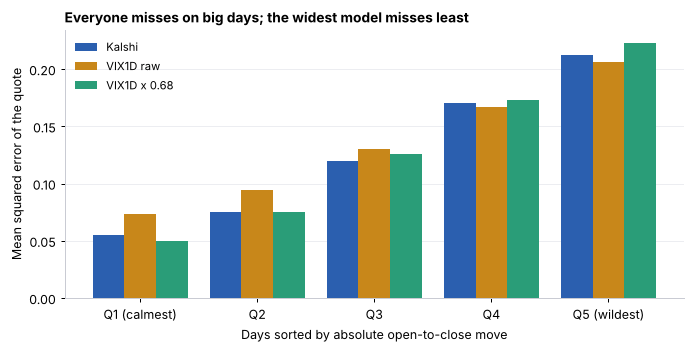

/tmp/ipykernel_301/392129905.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top[['date', 'r_oc', 'z', 'VIX1D_spxprev', 'nq', 'ek', 'er', 'es']].round(4))


,date,r_oc,z,VIX1D_spxprev,nq,ek,er,es
92,2024-04-04,-0.0186,-3.1418,9.43,1,0.3422,0.1791,0.1511
230,2025-02-27,-0.0203,-1.5761,20.49,3,0.2917,0.2356,0.2705
232,2025-03-03,-0.0201,-1.7090,18.67,1,0.6241,0.4640,0.5733
256,2025-04-04,-0.0421,-1.9770,33.83,3,0.0816,0.1009,0.0857
257,2025-04-07,0.0217,0.4204,81.89,3,0.1705,0.1600,0.1468
258,2025-04-08,-0.0414,-0.9902,66.51,1,0.0036,0.0229,0.0039
259,2025-04-09,0.0944,2.0398,73.57,3,0.2706,0.2860,0.3012
261,2025-04-11,0.0203,0.5743,56.20,3,0.2207,0.2611,0.2712
268,2025-04-24,0.0190,0.9950,30.40,2,0.3213,0.2960,0.3240
376,2025-10-10,-0.0283,-3.9680,11.33,2,0.4190,0.3478,0.4090


12 largest moves, mean squared error: {'kalshi': 0.276, 'raw': 0.247, 'scaled': 0.267}
calmer half of days: {'kalshi': 0.072, 'raw': 0.089, 'scaled': 0.071}


In [10]:
days['z'] = days.r_oc / (days.VIX1D_spxprev / 100 / SQ * TF)
s['e_k'] = (s.mid - s.result) ** 2; s['e_raw'] = (s.p_vix1d - s.result) ** 2; s['e_sc'] = (s.p_sc - s.result) ** 2
g = s.groupby('date').agg(nq=('mid', 'size'), ek=('e_k', 'mean'), er=('e_raw', 'mean'), es=('e_sc', 'mean')).reset_index()
dd = days.merge(g, on='date'); dd['abs'] = dd.r_oc.abs()
dd['q'] = pd.qcut(dd['abs'], 5, labels=['Q1 (calmest)', 'Q2', 'Q3', 'Q4', 'Q5 (wildest)'])
qt = dd.groupby('q', observed=True).agg(days=('date', 'size'), Kalshi=('ek', 'mean'), VIX1D_raw=('er', 'mean'), VIX1D_scaled=('es', 'mean')).reset_index()
R['move_quintiles'] = qt.to_dict('records'); display(qt.round(4))

fig, ax = plt.subplots(figsize=(7.8, 4.0)); x = np.arange(5); w = .27
for i, (col, lab, c) in enumerate([('Kalshi', 'Kalshi', BLUE), ('VIX1D_raw', 'VIX1D raw', ORNG), ('VIX1D_scaled', f'VIX1D x {k_tr:.2f}', GREEN)]):
    ax.bar(x + (i - 1) * w, qt[col], w, color=c, label=lab)
ax.set_xticks(x); ax.set_xticklabels([str(q) for q in qt.q]); ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_ylabel('Mean squared error of the quote'); ax.set_xlabel('Days sorted by absolute open-to-close move')
ax.set_title('Everyone misses on big days; the widest model misses least', loc='left', fontsize=11, fontweight='bold')
ax.grid(axis='x', visible=False); fig.tight_layout(); fig.savefig(f'{FIG}/f4_by_move_size.png'); plt.show()

top = dd.sort_values('abs', ascending=False).head(12).sort_values('date')
R['top12'] = dict(kalshi=float(top.ek.mean()), raw=float(top.er.mean()), scaled=float(top.es.mean()))
R['calm_half'] = dict(zip(['kalshi', 'raw', 'scaled'], [float(dd[dd['abs'] < dd['abs'].median()][c].mean()) for c in ['ek', 'er', 'es']]))
display(top[['date', 'r_oc', 'z', 'VIX1D_spxprev', 'nq', 'ek', 'er', 'es']].round(4))
print('12 largest moves, mean squared error:', {k: round(v, 3) for k, v in R['top12'].items()})
print('calmer half of days:', {k: round(v, 3) for k, v in R['calm_half'].items()})

## 7. Favorite / longshot check

,bk,n,days,price,freq,gap,lo,hi
0,"(-0.001, 0.03]",132,112,0.0192,0.0152,-0.0041,-0.0203,0.0269
1,"(0.03, 0.1]",175,161,0.0611,0.0229,-0.0382,-0.0563,-0.0130
2,"(0.1, 0.25]",205,194,0.1756,0.1659,-0.0098,-0.0611,0.0415
3,"(0.25, 0.5]",261,241,0.3700,0.3793,0.0093,-0.0547,0.0690
4,"(0.5, 0.75]",269,235,0.6396,0.6580,0.0184,-0.0446,0.0785
5,"(0.75, 0.9]",267,234,0.8367,0.8577,0.0210,-0.0296,0.0671
6,"(0.9, 0.97]",288,245,0.9418,0.9618,0.0200,-0.0036,0.0399
7,"(0.97, 1.0]",138,93,0.9838,1.0000,0.0162,0.0151,0.0174


Note: the top bucket has zero outcome variance (every contract paid), so its bootstrap interval is degenerate.


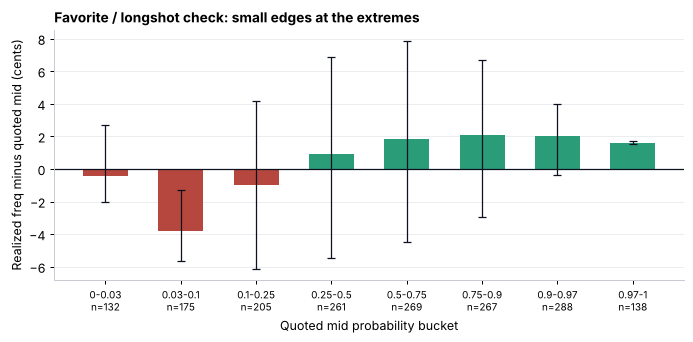

In [11]:
edges2 = [0, .03, .10, .25, .50, .75, .90, .97, 1.0]
s['bk'] = pd.cut(s.mid, edges2, include_lowest=True)
fb = s.groupby('bk', observed=True).agg(n=('mid', 'size'), days=('date', 'nunique'), price=('mid', 'mean'), freq=('result', 'mean')).reset_index()
fb['gap'] = fb.freq - fb.price
ci = [cboot(s[s.bk == b].assign(v=lambda t: t.result - t.mid), 'v') if s[s.bk == b].date.nunique() > 5 else (np.nan, np.nan) for b in fb.bk]
fb['lo'], fb['hi'] = [c[0] for c in ci], [c[1] for c in ci]
R['flb_buckets'] = fb.assign(bk=fb.bk.astype(str)).to_dict('records'); display(fb.round(4))
print('Note: the top bucket has zero outcome variance (every contract paid), so its bootstrap interval is degenerate.')
fig, ax = plt.subplots(figsize=(7.8, 3.9)); xs = np.arange(len(fb))
ax.bar(xs, fb.gap * 100, color=[GREEN if v >= 0 else RED for v in fb.gap], width=.6)
ax.errorbar(xs, fb.gap * 100, yerr=[(fb.gap - fb.lo) * 100, (fb.hi - fb.gap) * 100], fmt='none', ecolor=INK, capsize=3, lw=1)
ax.set_xticks(xs); ax.set_xticklabels([f'{max(b.left, 0):g}-{b.right:g}\nn={n}' for b, n in zip(fb.bk, fb.n)], fontsize=8)
ax.axhline(0, color=INK, lw=1); ax.set_ylabel('Realized freq minus quoted mid (cents)'); ax.set_xlabel('Quoted mid probability bucket')
ax.set_title('Favorite / longshot check: small edges at the extremes', loc='left', fontsize=11, fontweight='bold')
ax.grid(axis='x', visible=False); fig.tight_layout(); fig.savefig(f'{FIG}/f6_flb.png'); plt.show()

## 8. Backtests

In [12]:
def run_strategy(df, pcol, theta, rate, mode='touch'):
    """Buy YES at ask if model - ask - fee > theta, sell YES at bid if bid - model - fee > theta; hold to settlement."""
    x = df.dropna(subset=[pcol]); p = x[pcol].values
    pb, ps = (x.mid.values, x.mid.values) if mode == 'mid' else (x.ask.values, x.bid.values)
    buy = p - pb - fee(pb, rate); sell = ps - p - fee(ps, rate)
    side = np.where(buy > sell, 1, -1); edge = np.where(side == 1, buy, sell); m = edge > theta
    x = x[m].copy(); side = side[m]; px = np.where(side == 1, pb[m], ps[m]); y = x.result.values
    gross = np.where(side == 1, y - px, px - y)
    x['pnl'] = gross - fee(px, rate); x['gross'] = gross; x['side'] = side
    return x

def flb_rule(df, rate, hi=.95, lo=.05):
    a = df[df.mid >= hi].copy(); a['px'] = a.ask; a['pnl'] = a.result - a.px - fee(a.px, rate); a['side'] = 'fav'
    b = df[df.mid <= lo].copy(); b['px'] = b.bid; b['pnl'] = b.px - b.result - fee(b.px, rate); b['side'] = 'long'
    return pd.concat([a, b])

def gapfill(c, gap=30):
    idx, out = list(c.index), []
    for i, (a, v) in enumerate(c.items()):
        if i > 0 and (a - idx[i - 1]).days > gap: out.append((idx[i - 1] + pd.Timedelta(days=1), np.nan))
        out.append((a, v))
    return pd.Series([v for _, v in out], index=pd.DatetimeIndex([a for a, _ in out]))

### 8a. Favorite / longshot rule

In [13]:
rows = []
for rate in [0.0, 0.035, 0.07]:
    f = flb_rule(s, rate); lo, hi = cboot(f, 'pnl')
    rows.append(dict(fee_rate=rate, signals=len(f), days=f.date.nunique(), mean_cents=f.pnl.mean() * 100, lo_c=lo * 100, hi_c=hi * 100,
                     fav_cents=f[f.side == 'fav'].pnl.mean() * 100, n_fav=int((f.side == 'fav').sum()),
                     long_cents=f[f.side == 'long'].pnl.mean() * 100, n_long=int((f.side == 'long').sum())))
R['flb_rule'] = rows; display(pd.DataFrame(rows).round(3))
print('Average quoted spread over the sample (cents):', round((s.ask - s.bid).mean() * 100, 2))

,fee_rate,signals,days,mean_cents,lo_c,hi_c,fav_cents,n_fav,long_cents,n_long
0,0.000,474,296,0.414,-0.734,1.232,0.494,265,0.311,209
1,0.035,474,296,0.371,-0.773,1.190,0.452,265,0.268,209
2,0.070,474,296,0.328,-0.815,1.147,0.409,265,0.224,209


Average quoted spread over the sample (cents): 3.7


### 8b. Walk-forward: refit k every month on prior data only, then trade

In [14]:
s = s.sort_values(['date', 'strike']).reset_index(drop=True)
s['ym'] = s.date.dt.to_period('M'); s['p_wf'] = np.nan; kpath = {}
for m in [m for m in s.ym.unique() if m >= pd.Period('2024-01')]:
    hist = s[s.ym < m]
    if len(hist) < 60: continue
    k = fit_k(hist); kpath[str(m)] = k; idx = s.ym == m
    s.loc[idx, 'p_wf'] = model_p(s[idx], s.loc[idx, 'VIX1D'] / 100, k)
R['k_path'] = kpath
wf = s.dropna(subset=['p_wf']).copy()
R['wf_sample'] = dict(n=len(wf), days=int(wf.date.nunique()), start=str(wf.date.min().date()), end=str(wf.date.max().date()))
x = wf.assign(v=sq_gap(wf, 'p_wf')); lo, hi = cboot(x, 'v')
R['wf_brier'] = dict(kalshi=float(((wf.mid - wf.result) ** 2).mean()), walk_forward=float(((wf.p_wf - wf.result) ** 2).mean()), gap=float(x.v.mean()), lo=lo, hi=hi)
print(R['wf_sample']); print({k: round(v, 4) for k, v in R['wf_brier'].items()})
print('k range:', min(kpath.values()), '-', max(kpath.values()))

bt = []
for rate in [0.0, 0.035, 0.07]:
    for theta in [0.0, 0.02, 0.05]:
        for mode in ['touch', 'mid']:
            t = run_strategy(wf, 'p_wf', theta, rate, mode)
            if len(t) < 10: continue
            lo, hi = cboot(t, 'pnl')
            bt.append(dict(execution='cross the spread' if mode == 'touch' else 'fill at the mid', fee_rate=rate, min_edge=theta, trades=len(t),
                           days=t.date.nunique(), mean_cents=t.pnl.mean() * 100, lo_c=lo * 100, hi_c=hi * 100, total_usd=t.pnl.sum(),
                           buys=int((t.side == 1).sum()), sells=int((t.side == -1).sum())))
bt = pd.DataFrame(bt); R['backtests'] = bt.to_dict('records')
display(bt.round(3))

{'n': 1675, 'days': 570, 'start': '2024-01-03', 'end': '2026-10-08'}
{'kalshi': 0.1135, 'walk_forward': 0.1157, 'gap': 0.0023, 'lo': -0.0013, 'hi': 0.0059}
k range: 0.54 - 0.73


,execution,fee_rate,min_edge,trades,days,mean_cents,lo_c,hi_c,total_usd,buys,sells
0,cross the spread,0.000,0.00,1168,511,-1.184,-3.871,1.445,-13.830,577,591
1,fill at the mid,0.000,0.00,1675,570,1.023,-0.976,2.872,17.140,867,808
2,cross the spread,0.000,0.02,741,419,-0.005,-3.443,3.685,-0.040,322,419
3,fill at the mid,0.000,0.02,1072,509,0.584,-2.366,3.451,6.265,522,550
4,cross the spread,0.000,0.05,415,269,3.118,-2.246,8.576,12.940,140,275
5,fill at the mid,0.000,0.05,577,359,1.443,-2.959,5.813,8.325,221,356
6,cross the spread,0.035,0.00,1104,495,-1.431,-4.166,1.351,-15.795,543,561
7,fill at the mid,0.035,0.00,1608,562,0.902,-1.175,3.100,14.512,834,774
8,cross the spread,0.035,0.02,676,399,-0.598,-4.309,3.266,-4.041,284,392
9,fill at the mid,0.035,0.02,990,492,0.355,-2.645,3.342,3.512,484,506


raw VIX1D, fee 0.07, theta 0: {'trades': 1257, 'mean_cents': -3.94, 'lo_c': -5.94, 'hi_c': -1.85}
2024-01-01 -> 2024-12-31 -4.01
2025-01-01 -> 2025-12-31 -9.31
2026-01-01 -> 2026-06-30 2.55
2026-07-01 -> 2026-08-31 10.49
2026-09-01 -> 2026-10-31 -3.7
trough -13.76 2025-12-23 | peak 3.45 2026-07-27


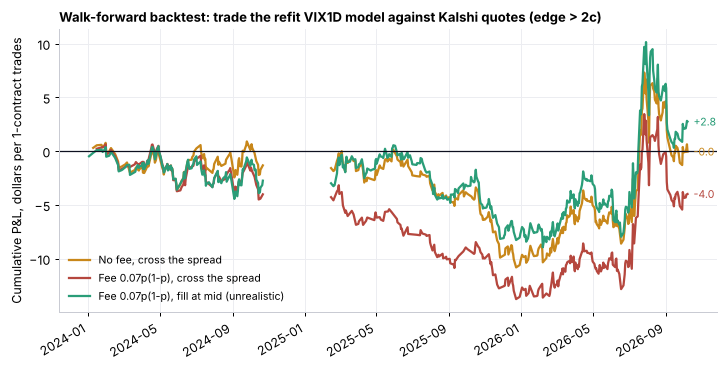

In [15]:
# Raw (unscaled) VIX1D for contrast, in-sample over the full sample, highest fee
t = run_strategy(s, 'p_vix1d', 0.0, 0.07, 'touch'); lo, hi = cboot(t, 'pnl')
R['raw_vix1d_strategy'] = dict(trades=len(t), mean_cents=float(t.pnl.mean() * 100), lo_c=lo * 100, hi_c=hi * 100)
print('raw VIX1D, fee 0.07, theta 0:', {k: round(v, 2) for k, v in R['raw_vix1d_strategy'].items()})

# Yearly P&L path of the realistic version (fee 0.07, cross the spread, 2c)
t = run_strategy(wf, 'p_wf', 0.02, 0.07, 'touch'); c = t.groupby('date').pnl.sum(); cc = c.cumsum()
for a, b in [('2024-01-01', '2024-12-31'), ('2025-01-01', '2025-12-31'), ('2026-01-01', '2026-06-30'), ('2026-07-01', '2026-08-31'), ('2026-09-01', '2026-10-31')]:
    print(a, '->', b, round(c[a:b].sum(), 2))
print('trough', round(cc.min(), 2), cc.idxmin().date(), '| peak', round(cc.max(), 2), cc.idxmax().date())

fig, ax = plt.subplots(figsize=(8.2, 4.2))
for rate, mode, lab, col in [(0.0, 'touch', 'No fee, cross the spread', ORNG), (0.07, 'touch', 'Fee 0.07p(1-p), cross the spread', RED), (0.07, 'mid', 'Fee 0.07p(1-p), fill at mid (unrealistic)', GREEN)]:
    cum = gapfill(run_strategy(wf, 'p_wf', 0.02, rate, mode).groupby('date').pnl.sum().cumsum())
    ax.plot(cum.index, cum.values, color=col, lw=1.8, label=lab); ax.text(cum.index[-1], cum.dropna().values[-1], f'  {cum.dropna().values[-1]:+.1f}', color=col, va='center', fontsize=8.5)
ax.axhline(0, color=INK, lw=1); ax.set_ylabel('Cumulative P&L, dollars per 1-contract trades'); ax.legend(frameon=False, fontsize=8.5, loc='lower left')
ax.set_title('Walk-forward backtest: trade the refit VIX1D model against Kalshi quotes (edge > 2c)', loc='left', fontsize=10.5, fontweight='bold')
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(f'{FIG}/f7_walkforward.png'); plt.show()

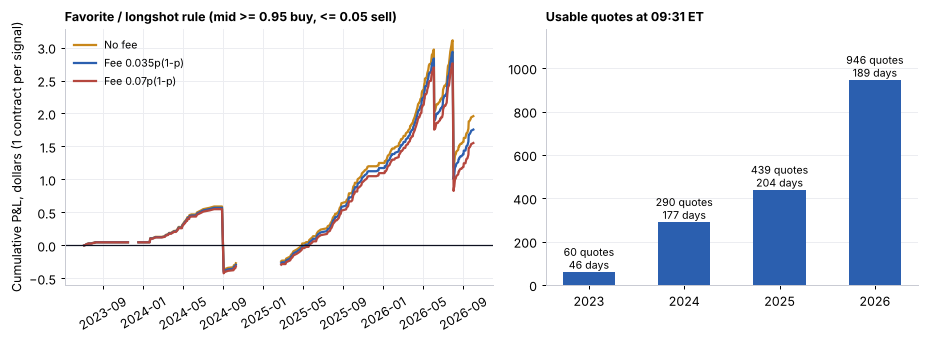

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10.4, 3.9), gridspec_kw={'width_ratios': [1.15, 1]}); ax = axs[0]
for rate, col, lab in [(0.0, ORNG, 'No fee'), (0.035, BLUE, 'Fee 0.035p(1-p)'), (0.07, RED, 'Fee 0.07p(1-p)')]:
    cum = gapfill(flb_rule(s, rate).groupby('date').pnl.sum().cumsum()); ax.plot(cum.index, cum.values, color=col, lw=1.8, label=lab)
ax.axhline(0, color=INK, lw=1); ax.legend(frameon=False, fontsize=8.5, loc='upper left'); ax.set_ylabel('Cumulative P&L, dollars (1 contract per signal)')
ax.set_title('Favorite / longshot rule (mid >= 0.95 buy, <= 0.05 sell)', loc='left', fontsize=10, fontweight='bold')
for l in ax.get_xticklabels(): l.set_rotation(30)
ax = axs[1]; cv = s.groupby('yr').agg(n=('mid', 'size'), days=('date', 'nunique')).reset_index()
ax.bar(cv.yr.astype(str), cv.n, color=BLUE, width=.55)
for i, r in cv.iterrows(): ax.text(i, r.n + 15, f'{r.n} quotes\n{r.days} days', ha='center', fontsize=8.5)
ax.set_ylim(0, cv.n.max() * 1.25); ax.set_title('Usable quotes at 09:31 ET', loc='left', fontsize=10, fontweight='bold'); ax.grid(axis='x', visible=False)
fig.tight_layout(); fig.savefig(f'{FIG}/f8_flb_and_coverage.png'); plt.show()

### 8c. Monotonicity: any crossed pair on the ladder?

In [17]:
def mono_scan(df, rate, max_dt=3600):
    n_ev = g_ev = n_net = pairs = 0
    for _, g in df.groupby('event'):
        b = g.sort_values('strike')[['strike', 'bid', 'ask', 'quote_ts']].values; n_ev += 1; found = net = False
        for i in range(len(b)):
            for j in range(i + 1, len(b)):
                if abs(b[i][3] - b[j][3]) > max_dt: continue
                gr = b[j][1] - b[i][2]          # bid of the higher strike minus ask of the lower strike
                if gr > 0:
                    found = True; pairs += 1
                    if gr - fee(b[i][2], rate) - fee(b[j][1], rate) > 0: net = True
        g_ev += found; n_net += net
    return dict(events=n_ev, events_with_crossed_pair=g_ev, net_of_fees=n_net, pairs=pairs)
R['mono'] = {f'fee {r}': mono_scan(s, r) for r in [0.0, 0.07]}; R['mono']

{'fee 0.0': {'events': 616,
  'events_with_crossed_pair': 0,
  'net_of_fees': 0,
  'pairs': 0},
 'fee 0.07': {'events': 616,
  'events_with_crossed_pair': 0,
  'net_of_fees': 0,
  'pairs': 0}}

## 9. Stability check: before and after July 2026

In [18]:
for lab, m in [('before 2026-07', s.date < '2026-07-01'), ('from 2026-07', s.date >= '2026-07-01')]:
    x = s[m]; r = compare(x, 'p_vix1d'); print(f'{lab:15s} quotes={r["n"]:4d} days={x.date.nunique():3d}  raw VIX1D - Kalshi = {r["gap"]:+.4f}  [{r["lo"]:+.4f}, {r["hi"]:+.4f}]')

before 2026-07  quotes=1189 days=547  raw VIX1D - Kalshi = +0.0085  [+0.0052, +0.0116]
from 2026-07    quotes= 546 days= 69  raw VIX1D - Kalshi = +0.0058  [-0.0033, +0.0143]


## 10. Check against the numbers quoted in the article

In [19]:
checks = [('Kalshi Brier (full)', R['brier_kalshi_all'], 0.1133, 4), ('VIX 30d Brier', R['table1']['VIX (30-day)']['brier'], 0.1292, 4),
          ('VIX1D Brier', R['table1']['VIX1D']['brier'], 0.1209, 4), ('k (pre-2025 fit)', R['k_train'], 0.68, 2),
          ('overnight variance share', R['overnight_var_share'], 0.287, 3), ('VIX1D open-to-close ratio', R['rms_ratio']['VIX1D']['oc'], 0.784, 3),
          ('walk-forward quotes', R['wf_sample']['n'], 1675, 0), ('walk-forward Brier', R['wf_brier']['walk_forward'], 0.1157, 4),
          ('FLB signals', R['flb_rule'][2]['signals'], 474, 0)]
bad = 0
for name, got, want, nd in checks:
    ok = round(float(got), nd) == round(float(want), nd); bad += (not ok)
    print(f'{"OK " if ok else "DIFF"} {name:28s} notebook={float(got):.4f} article={want}')
os.makedirs('data', exist_ok=True); json.dump(R, open('data/results.json', 'w'), indent=1, default=str)
print('\nmismatches:', bad)

OK  Kalshi Brier (full)          notebook=0.1133 article=0.1133
OK  VIX 30d Brier                notebook=0.1292 article=0.1292
OK  VIX1D Brier                  notebook=0.1209 article=0.1209
OK  k (pre-2025 fit)             notebook=0.6800 article=0.68
OK  overnight variance share     notebook=0.2873 article=0.287
OK  VIX1D open-to-close ratio    notebook=0.7840 article=0.784
OK  walk-forward quotes          notebook=1675.0000 article=1675
OK  walk-forward Brier           notebook=0.1157 article=0.1157
OK  FLB signals                  notebook=474.0000 article=474

mismatches: 0
